In [1]:
# Install modern, maintained libraries
%pip install numpy pandas matplotlib statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd

# import pyflux as pf
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
data_a = pd.read_csv('data/cpu-full-a.csv', parse_dates=[0])
data_train_a = pd.read_csv('data/cpu-train-a.csv', parse_dates=[0])
data_test_a = pd.read_csv('data/cpu-test-a.csv', parse_dates=[0])

In [4]:
data_b = pd.read_csv('data/cpu-full-b.csv', parse_dates=[0])
data_train_b = pd.read_csv('data/cpu-train-b.csv', parse_dates=[0])
data_test_b = pd.read_csv('data/cpu-test-b.csv', parse_dates=[0])

Text(0.5, 1.0, 'CPU Utilization')

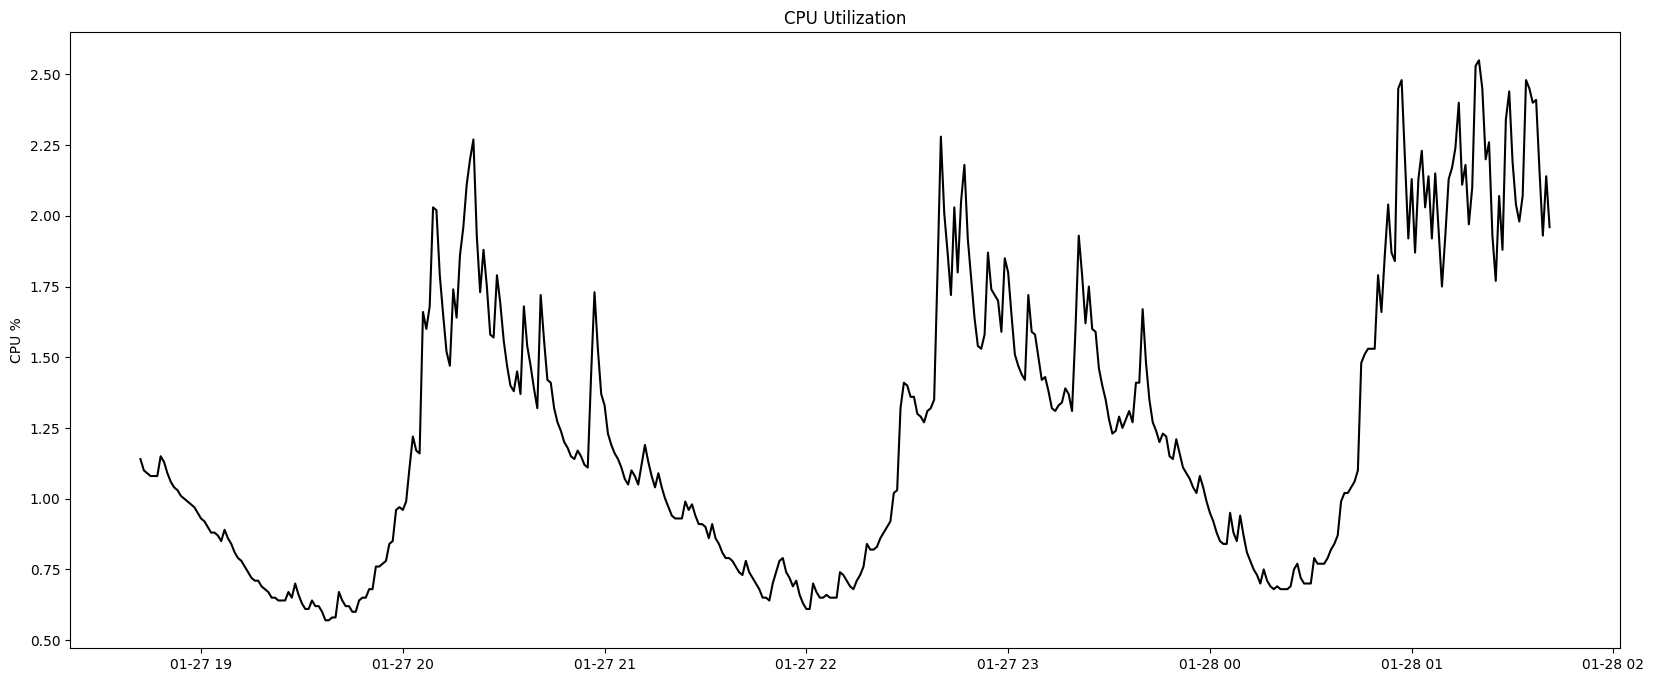

In [5]:
plt.figure(figsize=(20,8))
plt.plot(data_train_a['datetime'], data_train_a['cpu'], color='black')
plt.ylabel('CPU %')
plt.title('CPU Utilization')

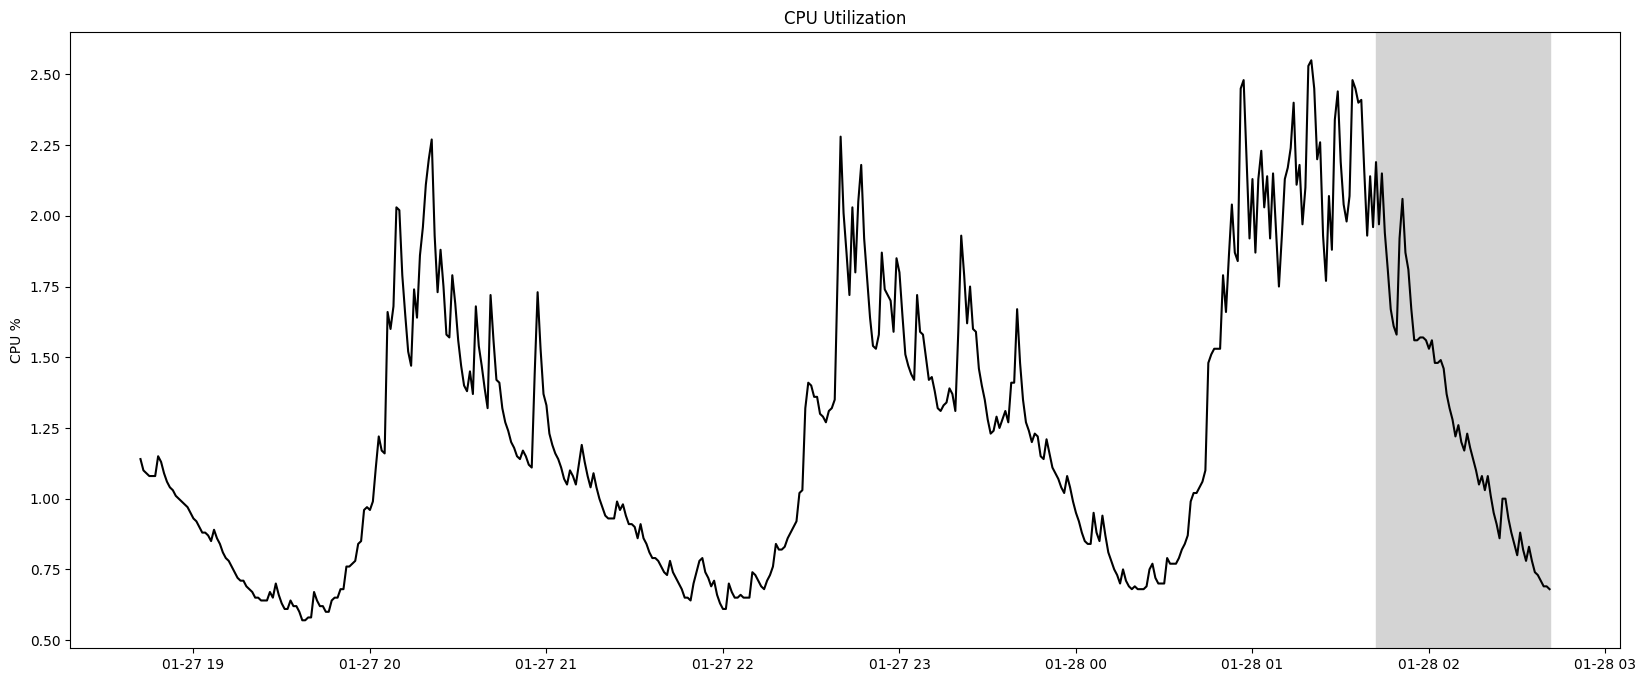

In [6]:
plt.figure(figsize=(20,8))
plt.plot(data_a['datetime'], data_a['cpu'], color='black')
plt.ylabel('CPU %')
plt.title('CPU Utilization')
plt.axvspan(xmin=pd.Timestamp(datetime(2017,1,28,1,42)), xmax=pd.Timestamp(datetime(2017,1,28,2,41)), color='#d4d4d4')

Text(0.5, 1.0, 'CPU Utilization')

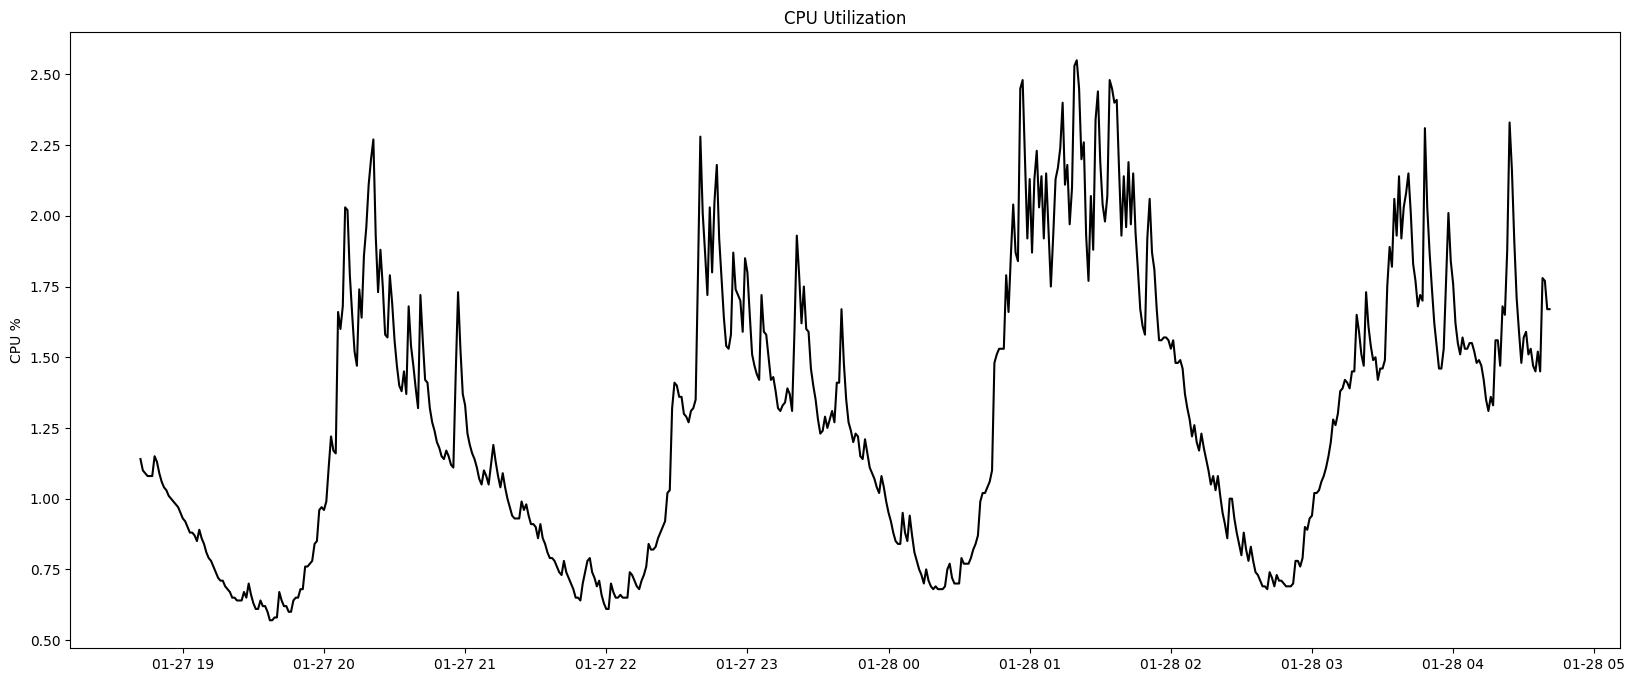

In [7]:
plt.figure(figsize=(20,8))
plt.plot(data_train_b['datetime'], data_train_b['cpu'], color='black')
plt.ylabel('CPU %')
plt.title('CPU Utilization')

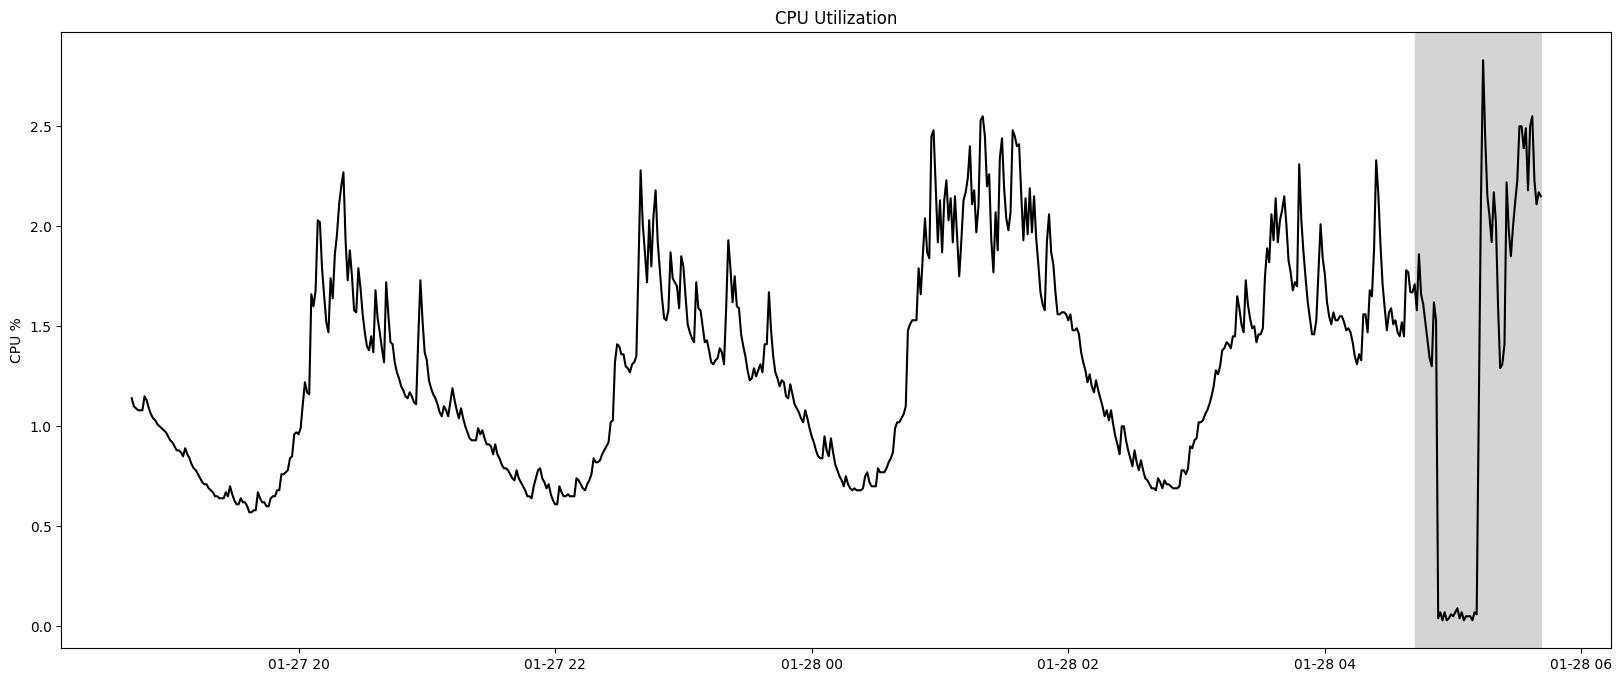

In [8]:
plt.figure(figsize=(20,8))
plt.plot(data_b['datetime'], data_b['cpu'], color='black')
plt.ylabel('CPU %')
plt.title('CPU Utilization')
plt.axvspan(xmin=pd.Timestamp(datetime(2017,1,28,4,42)), xmax=pd.Timestamp(datetime(2017,1,28,5,41)), color='#d4d4d4')

In [9]:
# 2. Set the index
data_train_a = data_train_a.set_index('datetime')

# 3. Handle Duplicates (Crucial for asfreq to work)
# This keeps the first occurrence if there are multiple rows for the same minute
data_train_a = data_train_a[~data_train_a.index.duplicated(keep='first')]

# 4. Sort the Index (ARIMA requires chronological order)
data_train_a = data_train_a.sort_index()

# 5. Set the frequency to Minutes ('min' or 'T')
# This will fill in any missing minutes in your timeline with NaN
data_train_a = data_train_a.asfreq('min')

# 6. Fill missing values (NaNs) created by asfreq
# The new way in Pandas 2.0+ is .ffill() instead of .fillna(method='ffill')
data_train_a = data_train_a.ffill()

# Verify it worked
print(f"Frequency set to: {data_train_a.index.freq}")

Frequency set to: <Minute>


In [10]:
# 1. Load the data
# data_train_b = pd.read_csv(os.path.join(dataset_root, 'cpu-train-b.csv'), parse_dates=[0])

# 2. Set the index
data_train_b = data_train_b.set_index('datetime')

# 3. Handle Duplicates (Crucial for asfreq to work)
# This keeps the first occurrence if there are multiple rows for the same minute
data_train_b = data_train_b[~data_train_b.index.duplicated(keep='first')]

# 4. Sort the Index (ARIMA requires chronological order)
data_train_b = data_train_b.sort_index()

# 5. Set the frequency to Minutes ('min' or 'T')
# This will fill in any missing minutes in your timeline with NaN
data_train_b = data_train_b.asfreq('min')

# 6. Fill missing values (NaNs) created by asfreq
# The new way in Pandas 2.0+ is .ffill() instead of .fillna(method='ffill')
data_train_b = data_train_b.ffill()

# Verify it worked
print(f"Frequency set to: {data_train_b.index.freq}")

Frequency set to: <Minute>


In [11]:
# Define and fit the model
# order=(AR, I, MA) -> (11, 0, 11)
model_a = ARIMA(data_train_a['cpu'], order=(11, 0, 11))
results_a = model_a.fit()

/media/shanmukha/DATA2/Acads/Sem_8/AI-for-cybersecurity/arima-example/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/media/shanmukha/DATA2/Acads/Sem_8/AI-for-cybersecurity/arima-example/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


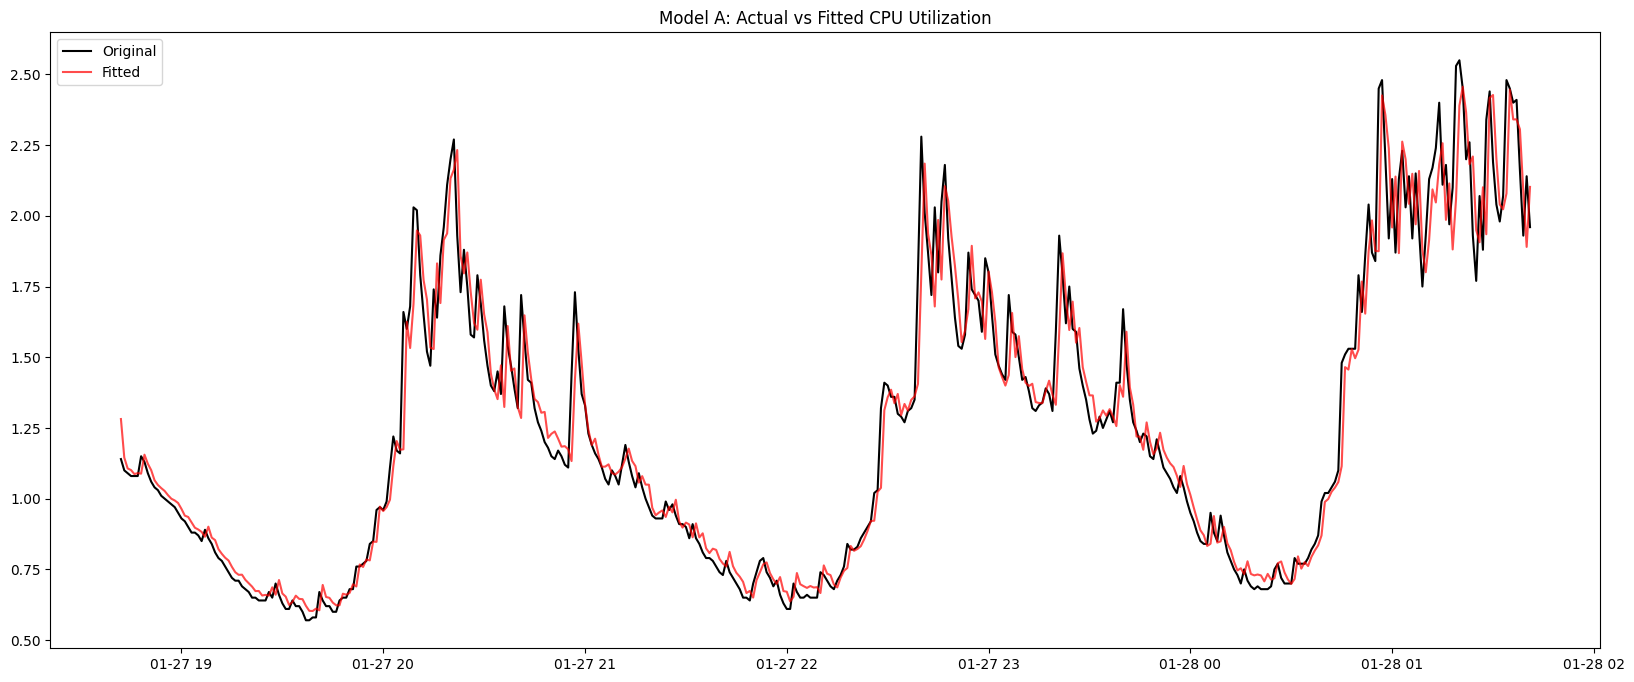

In [12]:
# Plot the fit (Comparison of original vs fitted values)
plt.figure(figsize=(20,8))
plt.plot(data_train_a['cpu'], color='black', label='Original')
plt.plot(results_a.fittedvalues, color='red', alpha=0.7, label='Fitted')
plt.title('Model A: Actual vs Fitted CPU Utilization')
plt.legend()
plt.show()


In [13]:
# Forecast 60 steps ahead (Equivalent to h=60)
forecast_a = results_a.get_forecast(steps=60)
forecast_mean = forecast_a.predicted_mean
conf_int = forecast_a.conf_int()

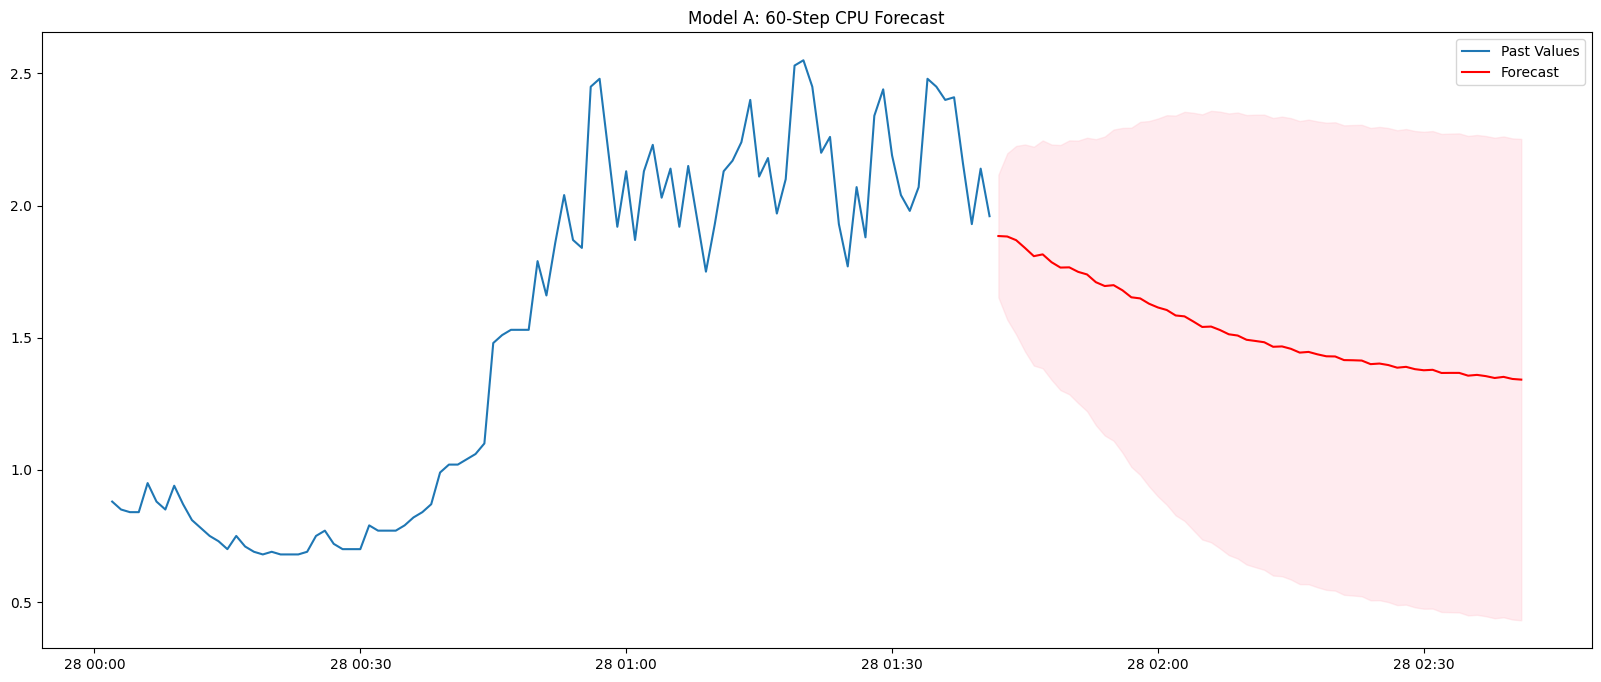

In [14]:
# Plot prediction
plt.figure(figsize=(20,8))
plt.plot(data_train_a['cpu'].iloc[-100:], label='Past Values') # last 100 values
plt.plot(forecast_mean, color='red', label='Forecast')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('Model A: 60-Step CPU Forecast')
plt.legend()
plt.show()

In [15]:
# Define and fit the model
# order=(AR, I, MA) -> (11, 0, 11)
model_b = ARIMA(data_train_b['cpu'], order=(11, 0, 11))
results_b = model_b.fit()

/media/shanmukha/DATA2/Acads/Sem_8/AI-for-cybersecurity/arima-example/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/media/shanmukha/DATA2/Acads/Sem_8/AI-for-cybersecurity/arima-example/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


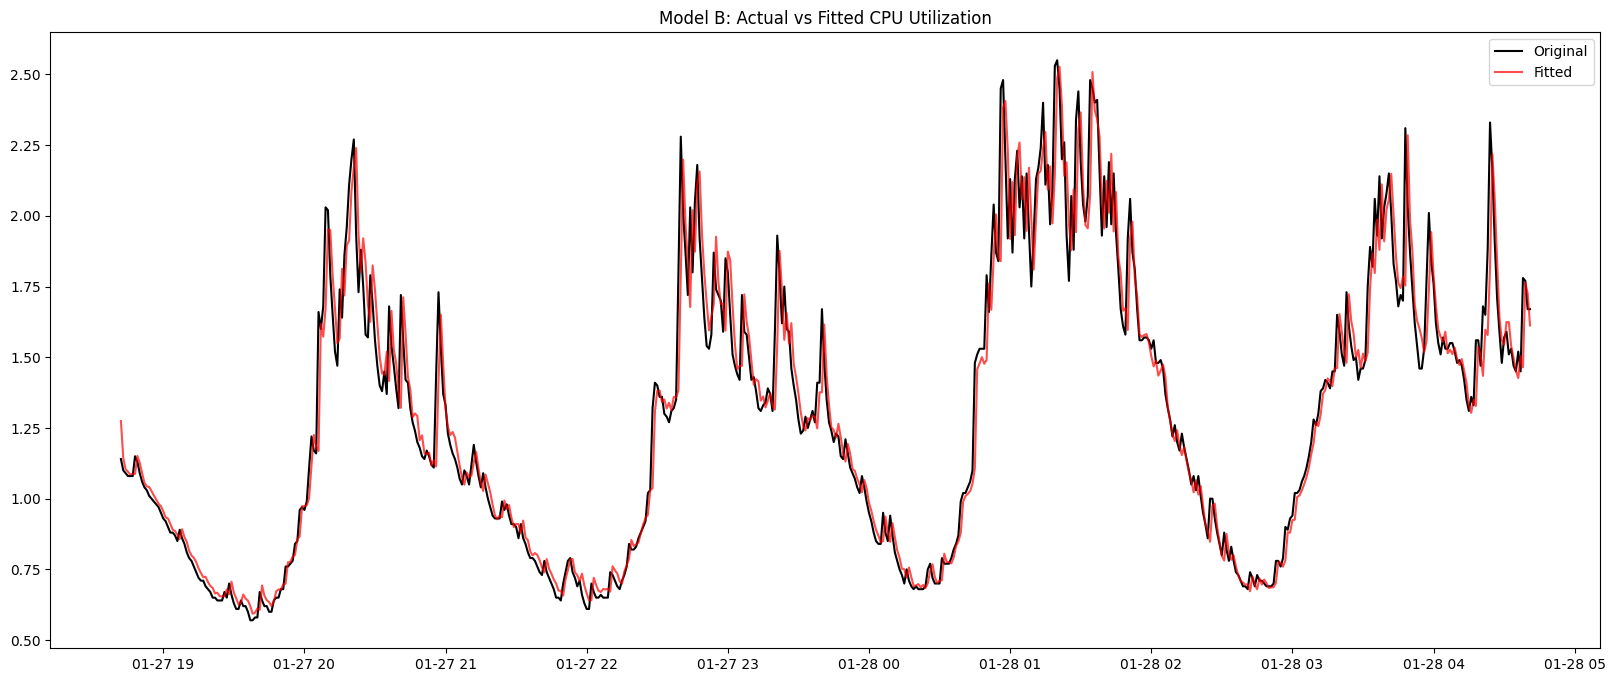

In [22]:
# Plot the fit (Comparison of original vs fitted values)
plt.figure(figsize=(20,8))
plt.plot(data_train_b['cpu'], color='black', label='Original')
plt.plot(results_b.fittedvalues, color='red', alpha=0.7, label='Fitted')
plt.title('Model B: Actual vs Fitted CPU Utilization')
plt.legend()
plt.show()


In [17]:
# Forecast 60 steps ahead (Equivalent to h=60)
forecast_b = results_b.get_forecast(steps=60)
forecast_mean = forecast_b.predicted_mean
conf_int = forecast_b.conf_int()

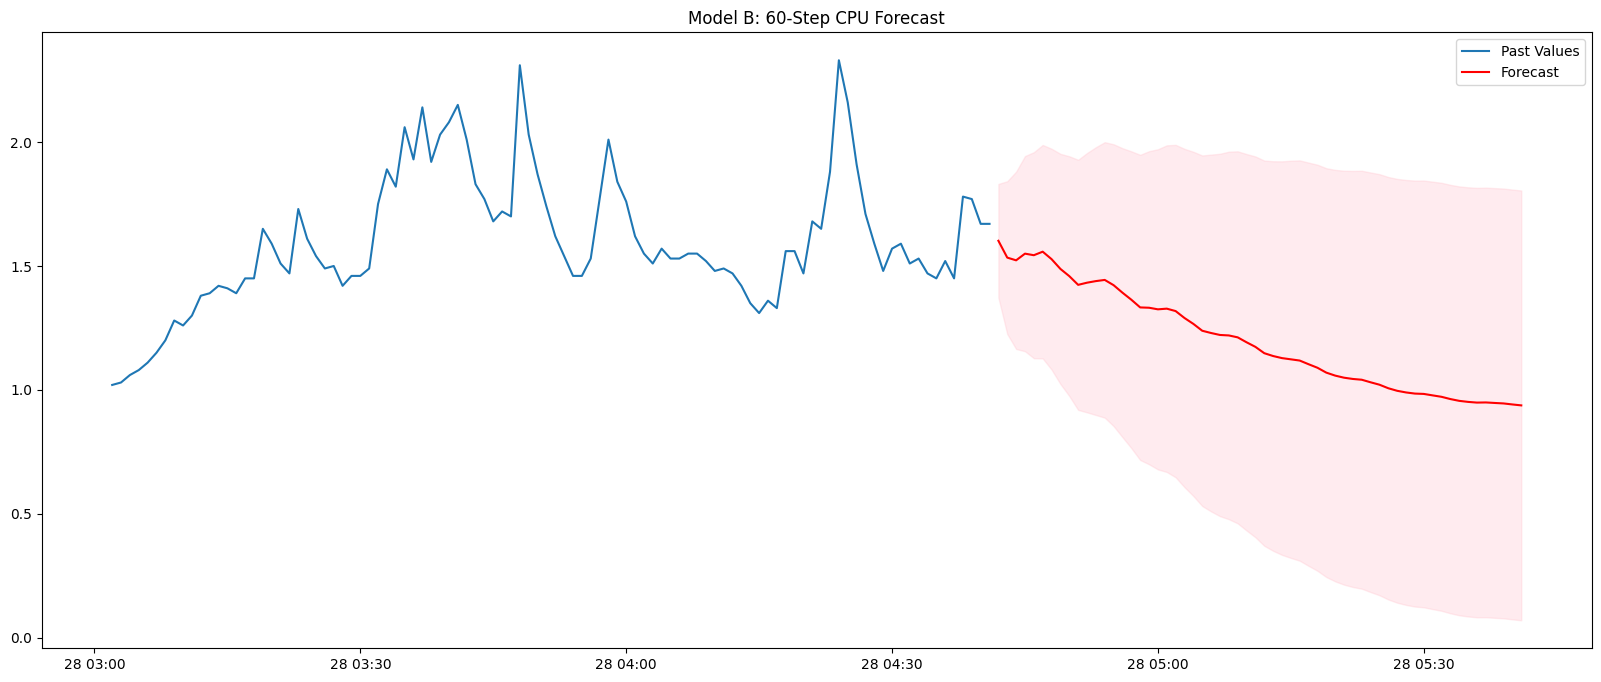

In [23]:
# Plot prediction
plt.figure(figsize=(20,8))
plt.plot(data_train_b['cpu'].iloc[-100:], label='Past Values') # last 100 values
plt.plot(forecast_mean, color='red', label='Forecast')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('Model B: 60-Step CPU Forecast')
plt.legend()
plt.show()

In [19]:
# model_a = pf.ARIMA(data=data_train_a, ar=11, ma=11, integ=0, target='cpu')
# x = model_a.fit("M-H")
# model_a.plot_fit(figsize=(20,8))
# model_a.plot_predict(h=60,past_values=100,figsize=(20,8))

In [20]:
# model_a.plot_predict_is(h=60, figsize=(20,8))

In [21]:
# model_b = pf.ARIMA(data=data_train_b, ar=11, ma=11, integ=0, target='cpu')
# x = model_b.fit("M-H")
# model_b.plot_predict(h=60,past_values=100,figsize=(20,8))